<a href="https://colab.research.google.com/github/bisu617/ai-misinformation-detection/blob/main/model-stage1/roberta_ai_or_human_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install -q datasets transformers accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [ ]:

import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA available: True
Device: Tesla T4


In [ ]:

# Loading dataset from huggingface

from datasets import load_dataset

dataset = load_dataset("artem9k/ai-text-detection-pile")
print(dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007-bc5952582e004d(…):   0%|          | 0.00/758M [00:00<?, ?B/s]

data/train-00001-of-00007-71c80017bc45f3(…):   0%|          | 0.00/318M [00:00<?, ?B/s]

data/train-00002-of-00007-ee2d43f396e78f(…):   0%|          | 0.00/125M [00:00<?, ?B/s]

...

data/train-00004-of-00007-b269dc49374a2c(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00005-of-00007-3dce5e05ddbad7(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

data/train-00006-of-00007-3d8a471ba0cf1c(…):   0%|          | 0.00/242M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1392522 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['source', 'id', 'text'],
        num_rows: 1392522
    })
})


In [ ]:

# saving to disk
dataset.save_to_disk("ai_text_detection_pile")



 #creating 100k sample train +10k

from datasets import load_from_disk
import re

ds_full = load_from_disk("ai_text_detection_pile")["train"].shuffle(seed=123)

train_part = ds_full.select(range(100_000))
val_part   = ds_full.select(range(100_000, 110_000))
test_part  = ds_full.select(range(110_000, 120_000))

print('Train:', len(train_part))
print('Val:  ', len(val_part))
print('Test: ', len(test_part))


Saving the dataset (0/7 shards):   0%|          | 0/1392522 [00:00<?, ? examples/s]

Train: 100000
Val:   10000
Test:  10000


In [ ]:

#cleaning text
def clean_text(ex):
    t = ex["text"]
    if t is None:
        t = ""
    t = str(t)
    ex["text"] = re.sub(r"\s+", " ", t).strip()
    return ex

train_part = train_part.map(clean_text)
val_part   = val_part.map(clean_text)
test_part  = test_part.map(clean_text)

train_part = train_part.filter(lambda x: len(x["text"]) >= 30)
val_part   = val_part.filter(lambda x: len(x["text"]) >= 30)
test_part  = test_part.filter(lambda x: len(x["text"]) >= 30)

print('After cleaning:')
print('Train:', len(train_part))
print('Val:  ', len(val_part))
print('Test: ', len(test_part))


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

After cleaning:
Train: 99916
Val:   9988
Test:  9990


In [ ]:

#label encoding 1 for ai 0 for human
label2id = {"human": 0, "ai": 1}
id2label = {0: "human", 1: "ai"}

def encode_label(ex):
    return {"label": label2id[ex["source"]]}

train_part = train_part.map(encode_label)
val_part   = val_part.map(encode_label)
test_part  = test_part.map(encode_label)

# Keep only text and label columns
cols_to_keep = ["text", "label"]
train_part = train_part.remove_columns([c for c in train_part.column_names if c not in cols_to_keep])
val_part   = val_part.remove_columns([c for c in val_part.column_names if c not in cols_to_keep])
test_part  = test_part.remove_columns([c for c in test_part.column_names if c not in cols_to_keep])

print('Labels encoded!')
print(train_part)


Map:   0%|          | 0/99916 [00:00<?, ? examples/s]

Map:   0%|          | 0/9988 [00:00<?, ? examples/s]

Map:   0%|          | 0/9990 [00:00<?, ? examples/s]

Labels encoded!
Dataset({
    features: ['text', 'label'],
    num_rows: 99916
})


In [ ]:
#tokeinizing
from transformers import AutoTokenizer

model_name = 'roberta-base'
tokenizer  = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128, padding='max_length')

train_tok = train_part.map(tokenize, batched=True, remove_columns=['text'])
val_tok   = val_part.map(tokenize,   batched=True, remove_columns=['text'])
test_tok  = test_part.map(tokenize,  batched=True, remove_columns=['text'])

train_tok.set_format('torch')
val_tok.set_format('torch')
test_tok.set_format('torch')

print('Tokenization done!')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/99916 [00:00<?, ? examples/s]

Map:   0%|          | 0/9988 [00:00<?, ? examples/s]

Map:   0%|          | 0/9990 [00:00<?, ? examples/s]

Tokenization done!


In [ ]:
#loading model and defining metrics

import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

acc_metric = evaluate.load('accuracy')
f1_metric  = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': acc_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1':       f1_metric.compute(predictions=preds,  references=labels, average='binary')['f1']
    }

print('Model loaded!')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!


In [ ]:

args = TrainingArguments(
    output_dir='roberta_stage1',
    eval_strategy='steps',
    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=False,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none'
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
torch.cuda.empty_cache()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
#train
train_result = trainer.train()
print('\nTraining complete!')
print(f"Total train time : {train_result.metrics['train_runtime']:.1f}s")
print(f"Train samples/sec: {train_result.metrics['train_samples_per_second']:.1f}")

Step,Training Loss,Validation Loss,Accuracy,F1
500,0.197270,0.156282,0.936724,0.886981
1000,0.140665,0.212550,0.936824,0.890584
1500,0.132788,0.202811,0.943332,0.901394
2000,0.131931,0.181665,0.957149,0.923187
2500,0.133611,0.168499,0.955146,0.920624
3000,0.083468,0.133596,0.970264,0.945574
3500,0.095821,0.208665,0.957149,0.923952
4000,0.111398,0.229455,0.948138,0.909567
4500,0.093294,0.180909,0.960853,0.929916
5000,0.098702,0.207813,0.940228,0.896873


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete!
Total train time : 11313.3s
Train samples/sec: 26.5


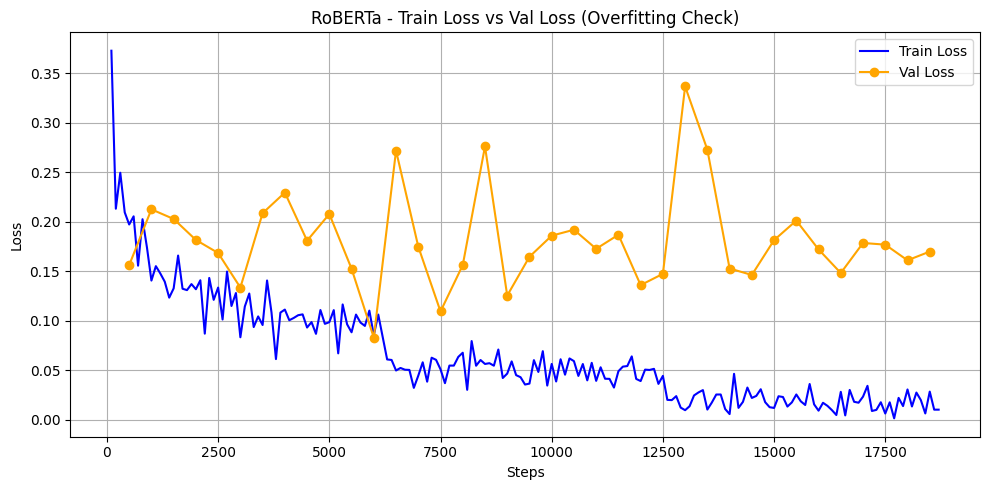

Overfitting plot done!


In [ ]:
#  Overfitting Plot

import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_steps  = [x['step'] for x in logs if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in logs if 'loss' in x and 'eval_loss' not in x]
val_steps    = [x['step'] for x in logs if 'eval_loss' in x]
val_losses   = [x['eval_loss'] for x in logs if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label='Train Loss', color='blue')
plt.plot(val_steps,   val_losses,   label='Val Loss',   color='orange', marker='o')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('RoBERTa - Train Loss vs Val Loss (Overfitting Check)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print('Overfitting plot done!')


In [ ]:
# Final Test Evaluation (F1 + Accuracy)
test_results = trainer.evaluate(test_tok)
print('\n========== FINAL TEST RESULTS ==========')
print(f"Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"F1 Score : {test_results['eval_f1']:.4f}")
print(f"Eval Loss: {test_results['eval_loss']:.4f}")
print('=========================================')



========== FINAL TEST RESULTS ==========
Accuracy : 0.9802
F1 Score : 0.9638
Eval Loss: 0.0879



=== Classification Report ===
              precision    recall  f1-score   support

       Human       0.99      0.98      0.99      7309
          AI       0.94      0.98      0.96      2681

    accuracy                           0.98      9990
   macro avg       0.97      0.98      0.98      9990
weighted avg       0.98      0.98      0.98      9990



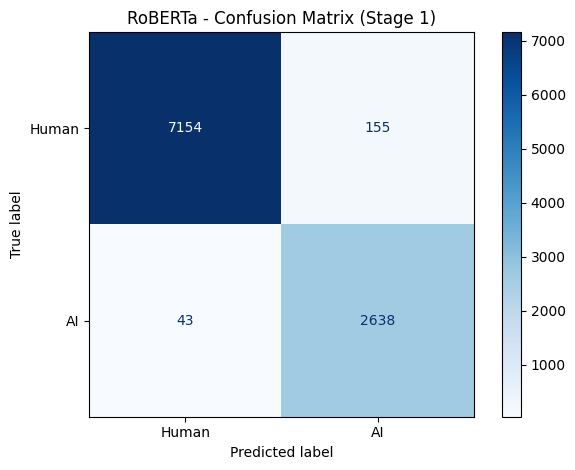

Confusion matrix done!


In [ ]:
#  Confusion Matrix + Classification Report

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

preds_output = trainer.predict(test_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
disp.plot(cmap='Blues')
plt.title('RoBERTa - Confusion Matrix (Stage 1)')
plt.tight_layout()
plt.show()
print('Confusion matrix done!')

In [ ]:
trainer.save_model("/content/drive/MyDrive/roberta_stage1_model")
tokenizer.save_pretrained("/content/drive/MyDrive/roberta_stage1_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/roberta_stage1_model/tokenizer_config.json',
 '/content/drive/MyDrive/roberta_stage1_model/tokenizer.json')